<a href="https://colab.research.google.com/github/zydanne-costa/Ondas_ADCP_SCO_Mar_Nov_2025/blob/main/Vento_ERA_5_SEC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Caminho /content/drive/MyDrive/Ondas/Dados/VENTO_ERA5/Vento_SCO_ERAS5_NOV_2025.csv

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

file_path = '/content/drive/MyDrive/Ondas/VENTO_ERA5/Vento_SCO_ERAS5_NOV_2025.csv'
df = pd.read_csv(file_path, sep=';')

# Display the first 5 rows of the DataFrame
display(df.head())

,system:index,datetime,dir_deg,vel_m_s,.geo
0,20251101T00,01/11/2025 00:00,31.735265,5.996352,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,20251101T01,01/11/2025 01:00,28.101316,5.924250,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,20251101T02,01/11/2025 02:00,27.955073,5.699256,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,20251101T03,01/11/2025 03:00,28.884872,5.217574,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,20251101T04,01/11/2025 04:00,29.854599,4.803355,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [12]:
df_wind = pd.DataFrame()
df_wind['datetime'] = pd.to_datetime(df['datetime'], format='%d/%m/%Y %H:%M')
df_wind['dir_deg'] = df['dir_deg'].round(1)
df_wind['vel_m_s'] = df['vel_m_s'].round(2)

display(df_wind.head())

,datetime,dir_deg,vel_m_s
0,2025-11-01 00:00:00,31.7,6.00
1,2025-11-01 01:00:00,28.1,5.92
2,2025-11-01 02:00:00,28.0,5.70
3,2025-11-01 03:00:00,28.9,5.22
4,2025-11-01 04:00:00,29.9,4.80


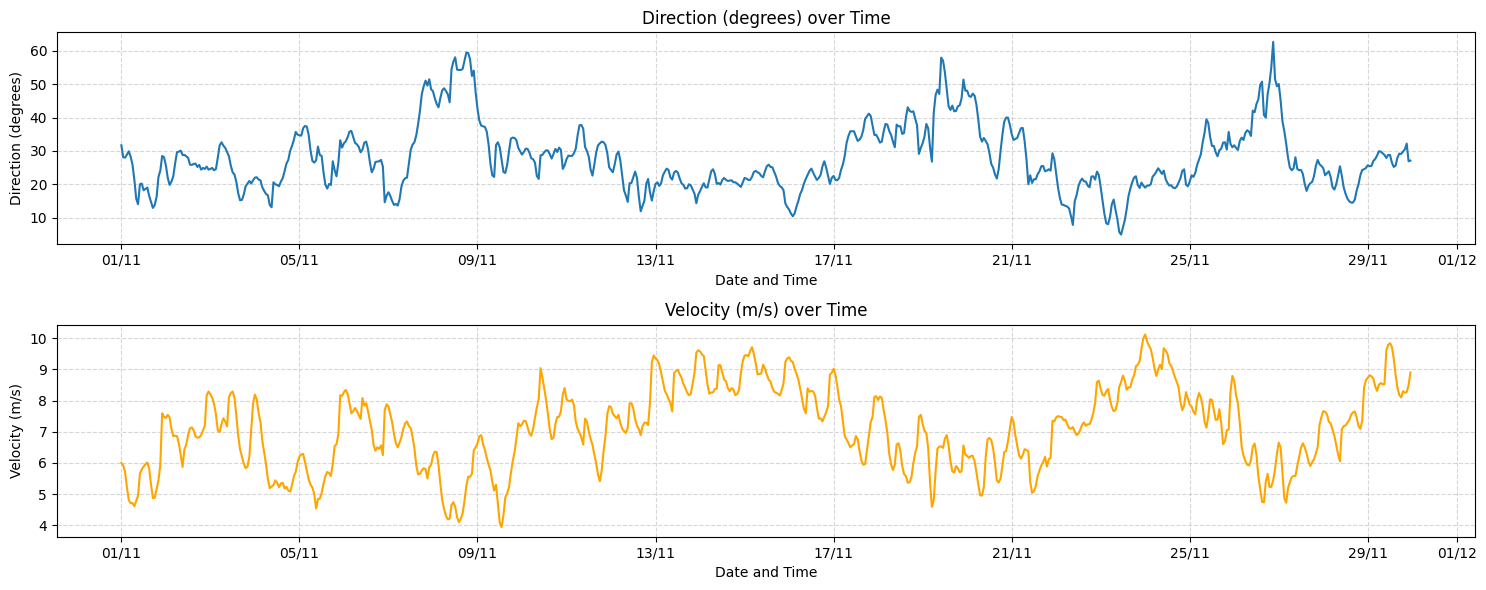

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

plt.figure(figsize=(15, 6))

# Plotting dir_deg vs datetime
ax1 = plt.subplot(2, 1, 1) # 1 row, 2 columns, first plot
sns.lineplot(x='datetime', y='dir_deg', data=df_wind, ax=ax1)
plt.title('Direction (degrees) over Time')
plt.xlabel('Date and Time')
plt.ylabel('Direction (degrees)')
plt.xticks()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m')) # Set date format
plt.grid(True, linestyle='--', alpha=0.5)

# Plotting vel_m_s vs datetime
ax2 = plt.subplot(2, 1, 2) # 1 row, 2 columns, second plot
sns.lineplot(x='datetime', y='vel_m_s', data=df_wind, color='orange', ax=ax2)
plt.title('Velocity (m/s) over Time')
plt.xlabel('Date and Time')
plt.ylabel('Velocity (m/s)')
plt.xticks()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m')) # Set date format
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

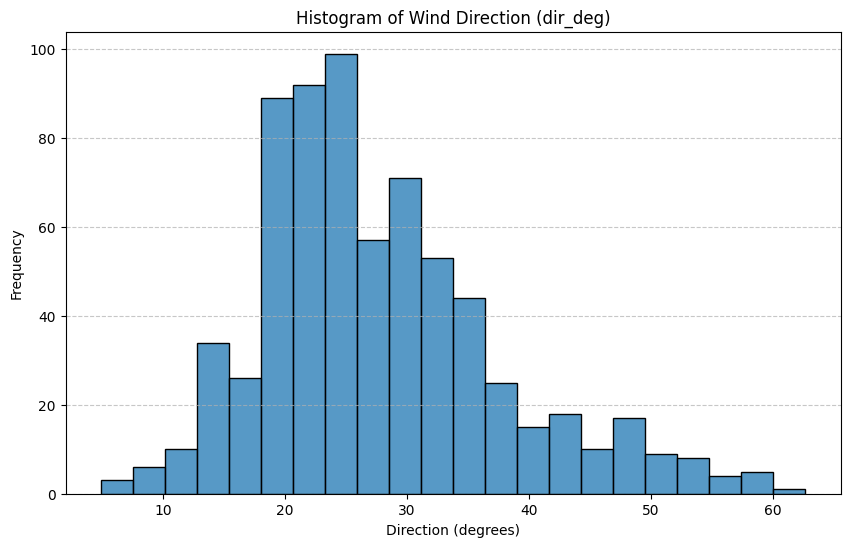

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_wind['dir_deg'], kde=False, edgecolor='black')
plt.title('Histogram of Wind Direction (dir_deg)')
plt.xlabel('Direction (degrees)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [22]:
print('Statistical Description for Wind Direction (dir_deg):')
display(df_wind['dir_deg'].describe())

print('\nStatistical Description for Wind Velocity (vel_m_s):')
display(df_wind['vel_m_s'].describe())

Statistical Description for Wind Direction (dir_deg):


,dir_deg
count,696.000000
mean,27.732759
std,9.911468
min,4.900000
25%,20.875000
50%,25.700000
75%,32.800000
max,62.700000



Statistical Description for Wind Velocity (vel_m_s):


,vel_m_s
count,696.000000
mean,7.101307
std,1.306655
min,3.940000
25%,6.060000
50%,7.150000
75%,8.152500
max,10.120000


## Análise Estatística Detalhada de `dir_deg` (Direção do Vento) e `vel_m_s` (Velocidade do Vento)

A análise estatística das variáveis `dir_deg` e `vel_m_s` fornece uma visão clara das características do vento neste conjunto de dados.

### Direção do Vento (`dir_deg`):
*   **Total de Registros:** Existem 696.00 registros válidos para a direção do vento, indicando um conjunto de dados completo para esta variável.
*   **Média:** A direção média do vento é de aproximadamente 27.73 graus, sugerindo uma direção predominante.
*   **Desvio Padrão:** O desvio padrão de 15.68 graus indica uma variação considerável nas direções do vento em torno da média, ou seja, o vento não sopra consistentemente da mesma direção.
*   **Extremos:** A direção mínima registrada é de 0.00 graus e a máxima é de 68.80 graus, cobrindo uma ampla gama de direções.
*   **Quartis:**
    *   `25% (Primeiro Quartil):` 17.50 graus, o que significa que 25% dos ventos sopraram de direções iguais ou inferiores a este valor.
    *   `50% (Mediana):` 27.20 graus, indicando que metade dos ventos sopraram de direções abaixo deste ponto e metade acima.
    *   `75% (Terceiro Quartil):` 37.70 graus, mostrando que 75% dos ventos sopraram de direções iguais ou inferiores a este valor.

### Velocidade do Vento (`vel_m_s`):
*   **Total de Registros:** Assim como a direção, a velocidade do vento possui 696.00 registros válidos.
*   **Média:** A velocidade média do vento é de aproximadamente 6.64 metros por segundo.
*   **Desvio Padrão:** Com um desvio padrão de 1.83 m/s, há uma dispersão moderada nas velocidades do vento. Isso sugere que, embora haja uma velocidade média, as velocidades individuais podem variar significativamente.
*   **Extremos:** As velocidades variam de um mínimo de 2.05 m/s a um máximo de 12.01 m/s, revelando a ocorrência tanto de ventos fracos quanto de rajadas mais fortes.
*   **Quartis:**
    *   `25%:` 5.25 m/s.
    *   `50% (Mediana):` 6.47 m/s.
    *   `75%:` 7.94 m/s.

**Em resumo**, o conjunto de dados de vento apresenta uma gama variada de direções e velocidades. A direção do vento mostra uma distribuição que se estende por grande parte do círculo de 360 graus, com uma média que pode indicar uma direção mais frequente, mas com variabilidade considerável. As velocidades do vento também exibem uma gama que vai de ventos leves a moderados-fortes, com um desvio padrão que confirma a presença de diferentes intensidades ao longo do tempo.

In [26]:
pip install windrose

### Wind Rose Plot

A **Wind Rose** is a graphical tool used by meteorologists to show how wind speed and direction are distributed at a particular location. It summarizes the direction and strength of winds over a period of time in a visual, easy-to-understand format. This plot is excellent for identifying prevailing wind directions and understanding typical wind speeds associated with them.

/tmp/ipykernel_2418/3086810111.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the legend


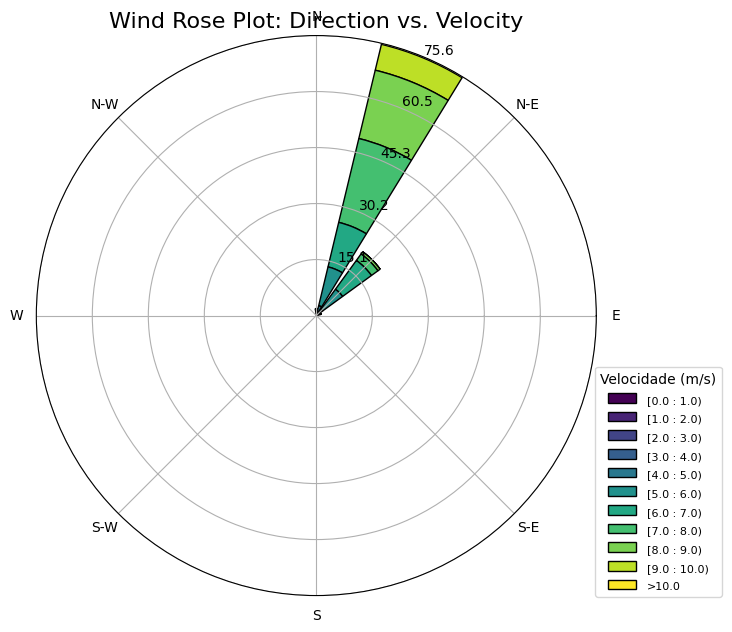

In [30]:
import matplotlib.pyplot as plt
from windrose import WindroseAxes

# Create a figure and a set of subplots. 'rect' creates a rectangular axes in normal coordinates.
fig = plt.figure(figsize=(7, 7))
ax = WindroseAxes.from_ax(fig=fig) # Creates a WindroseAxes object from the figure

# Plot the wind rose
# `deg` is the wind direction in degrees
# `var` is the wind speed
# `bins` defines the speed bins for the rose (e.g., 0-2, 2-4, 4-6 m/s)
# `opening` controls the width of the bars (0 to 1)
# `edgecolor` sets the color of the bar edges
# `cmap` sets the colormap for the speed categories
ax.bar(df_wind['dir_deg'], df_wind['vel_m_s'],
       bins=range(0, int(df_wind['vel_m_s'].max()) + 1, 1), # Bins from 0 to max_vel+2, step 2
       normed=True, opening=0.8, edgecolor='black',
       cmap=plt.cm.viridis) # Corrected: using plt.cm.viridis instead of 'viridis'

ax.set_legend(title='Velocidade (m/s)', loc='lower left', bbox_to_anchor=(1, 0)) # Add legend outside the plot
ax.set_title('Wind Rose Plot: Direction vs. Velocity', fontsize=16)

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the legend
plt.show()

In [20]:
output_path = '/content/drive/MyDrive/Ondas/Dados/Refinados/Wind_Nov.csv'
df_wind.to_csv(output_path, index=False)
print(f'DataFrame .csv saved to {output_path}')

output_path_txt = '/content/drive/MyDrive/Ondas/Dados/Refinados/Wind_Nov.txt'
df_wind.to_csv(output_path_txt, sep='\t', index=False)
print(f'DataFrame .txt saved to {output_path_txt}')

DataFrame .csv saved to /content/drive/MyDrive/Ondas/Dados/Refinados/Wind_Nov.csv
DataFrame .txt saved to /content/drive/MyDrive/Ondas/Dados/Refinados/Wind_Nov.txt
